# Этап 3
# Грузим мастер-таблицу

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Загружаем мастер-таблицу
master = pd.read_csv(
    '../data/processed_data/master_orders.csv',
    parse_dates=['order_purchase_timestamp']
)

print("Загружено:")
print(f"  Заказов: {len(master):,}")
print(f"  Клиентов: {master['customer_unique_id'].nunique():,}")
print(f"  Период: {master['order_purchase_timestamp'].min().date()} — {master['order_purchase_timestamp'].max().date()}")
print()
print("Колонки:")
print(master.columns.tolist())

Загружено:
  Заказов: 96,470
  Клиентов: 93,350
  Период: 2016-09-15 — 2018-08-29

Колонки:
['order_id', 'customer_unique_id', 'customer_state', 'order_purchase_timestamp', 'order_month', 'revenue', 'freight', 'payment_value', 'review_score', 'delivery_days', 'is_late', 'main_category']


# когорта для каждого клиента

In [2]:
# Для каждого клиента — дата первой покупки
first_purchase = (
    master
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'first_purchase_date'})
)

# Месяц когорты
first_purchase['cohort_month'] = (
    first_purchase['first_purchase_date'].dt.to_period('M')
)

print("Уникальных клиентов:", len(first_purchase))
print()
print("Топ-5 месяцев по числу новых клиентов:")
print(first_purchase['cohort_month'].value_counts().sort_index().head())
print()
print("Последние 5 месяцев:")
print(first_purchase['cohort_month'].value_counts().sort_index().tail())

Уникальных клиентов: 93350

Топ-5 месяцев по числу новых клиентов:
cohort_month
2016-09       1
2016-10     262
2016-12       1
2017-01     717
2017-02    1628
Freq: M, Name: count, dtype: int64

Последние 5 месяцев:
cohort_month
2018-04    6582
2018-05    6506
2018-06    5875
2018-07    5946
2018-08    6144
Freq: M, Name: count, dtype: int64


# Присоединяем когорту к каждому заказу

In [3]:
# Присоединяем cohort_month к каждому заказу
master = master.merge(
    first_purchase[['customer_unique_id', 'cohort_month']],
    on='customer_unique_id',
    how='left'
)

print("Пропусков в cohort_month:", master['cohort_month'].isnull().sum())
print()
print(master[['customer_unique_id', 'order_purchase_timestamp', 
              'cohort_month', 'order_month']].head(10))

Пропусков в cohort_month: 0

                 customer_unique_id order_purchase_timestamp cohort_month  \
0  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33      2017-09   
1  af07308b275d755c9edb36a90c618231      2018-07-24 20:41:37      2018-07   
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08-08 08:38:49      2018-08   
3  7c142cf63193a1473d2e66489a9ae977      2017-11-18 19:28:06      2017-11   
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02-13 21:18:39      2018-02   
5  80bb27c7c16e8f973207a5086ab329e2      2017-07-09 21:57:05      2017-07   
6  932afa1e708222e5821dac9cd5db4cae      2017-05-16 13:10:30      2017-05   
7  39382392765b6dc74812866ee5ee92a7      2017-01-23 18:29:09      2017-01   
8  299905e3934e9e181bfb2e164dd4b4f8      2017-07-29 11:55:02      2017-07   
9  f2a85dec752b8517b5e58a06ff3cd937      2017-05-16 19:41:10      2017-05   

  order_month  
0     2017-10  
1     2018-07  
2     2018-08  
3     2017-11  
4     2018-02  
5     2017-07  
6     2017-

# month_index — сколько месяцев прошло

In [4]:
# Считаем month_index: сколько месяцев прошло от когорты до заказа
master['month_index'] = (
    (master['order_month'].astype('period[M]') - 
     master['cohort_month'].astype('period[M]'))
    .apply(lambda x: x.n)
)

print("Распределение month_index:")
print(master['month_index'].value_counts().sort_index().head(15))

Распределение month_index:
month_index
0     94571
1       433
2       283
3       202
4       181
5       149
6       133
7       103
8        88
9        63
10       75
11       59
12       36
13       27
14       25
Name: count, dtype: int64


# retention matrix

In [5]:
# Считаем размер каждой когорты (сколько уникальных клиентов)
cohort_sizes = (
    first_purchase
    .groupby('cohort_month')['customer_unique_id']
    .nunique()
)

# Считаем уникальных клиентов по (cohort_month, month_index)
cohort_data = (
    master
    .groupby(['cohort_month', 'month_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

# Присоединяем размер когорты
cohort_data = cohort_data.merge(
    cohort_sizes.rename('cohort_size'),
    left_on='cohort_month',
    right_index=True
)

# Считаем retention как долю
cohort_data['retention'] = cohort_data['customer_unique_id'] / cohort_data['cohort_size']

# Превращаем в матрицу: строки = когорта, столбцы = month_index
retention_matrix = cohort_data.pivot(
    index='cohort_month',
    columns='month_index',
    values='retention'
)

print("Retention matrix:")
print(retention_matrix.head(10))
print()
print("Размер матрицы:", retention_matrix.shape)

Retention matrix:
month_index    0         1         2         3         4         5         6   \
cohort_month                                                                    
2016-09       1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2016-10       1.0       NaN       NaN       NaN       NaN       NaN  0.003817   
2016-12       1.0  1.000000       NaN       NaN       NaN       NaN       NaN   
2017-01       1.0  0.002789  0.002789  0.001395  0.004184  0.001395  0.004184   
2017-02       1.0  0.001843  0.003071  0.001229  0.004300  0.001229  0.002457   
2017-03       1.0  0.004395  0.003596  0.003995  0.003596  0.001598  0.001598   
2017-04       1.0  0.006206  0.002216  0.001773  0.002660  0.002660  0.003546   
2017-05       1.0  0.004638  0.004638  0.002899  0.002899  0.003188  0.004058   
2017-06       1.0  0.004939  0.003951  0.004281  0.002963  0.003951  0.003622   
2017-07       1.0  0.005330  0.003465  0.002399  0.002932  0.002132  0.003198   

month_ind

# Очищаем матрицу от мелких когорт

In [6]:
# Оставляем только когорты с 100+ клиентами
valid_cohorts = cohort_sizes[cohort_sizes >= 100].index
retention_matrix_clean = retention_matrix.loc[
    retention_matrix.index.isin(valid_cohorts)
]

# Ограничиваем период: 2017-01 — 2018-08
retention_matrix_clean = retention_matrix_clean.loc[
    (retention_matrix_clean.index >= '2017-01') & 
    (retention_matrix_clean.index <= '2018-08')
]

# Ограничиваем месяцы: только первые 12 (год)
retention_matrix_clean = retention_matrix_clean.iloc[:, :12]

print("Размер после очистки:", retention_matrix_clean.shape)
print()
print("Когорты:")
print(retention_matrix_clean.index.tolist())

Размер после очистки: (20, 12)

Когорты:
[Period('2017-01', 'M'), Period('2017-02', 'M'), Period('2017-03', 'M'), Period('2017-04', 'M'), Period('2017-05', 'M'), Period('2017-06', 'M'), Period('2017-07', 'M'), Period('2017-08', 'M'), Period('2017-09', 'M'), Period('2017-10', 'M'), Period('2017-11', 'M'), Period('2017-12', 'M'), Period('2018-01', 'M'), Period('2018-02', 'M'), Period('2018-03', 'M'), Period('2018-04', 'M'), Period('2018-05', 'M'), Period('2018-06', 'M'), Period('2018-07', 'M'), Period('2018-08', 'M')]


# Heatmap retention

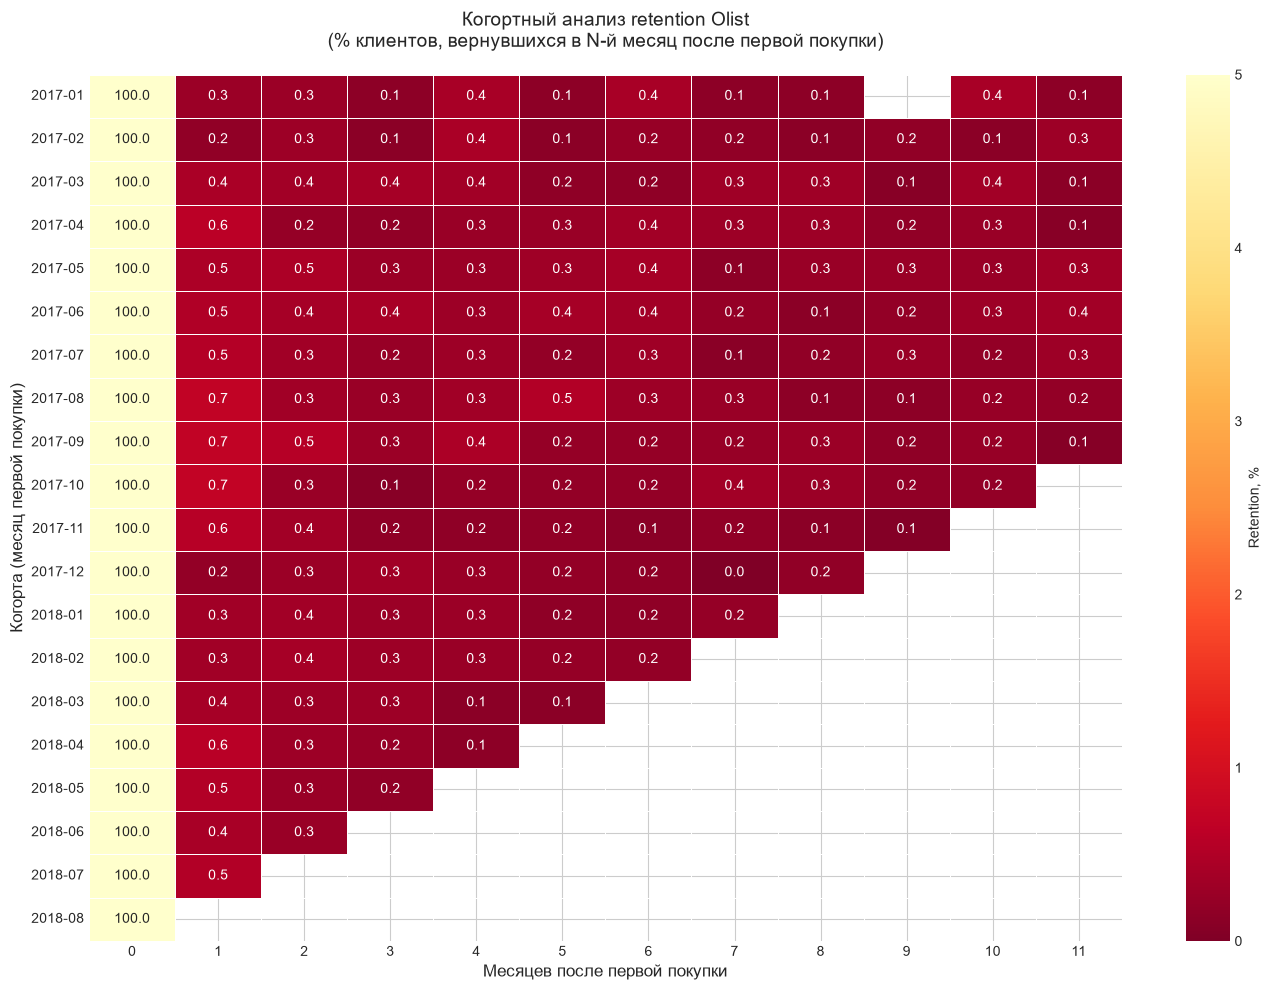

Сохранено: data/processed/retention_heatmap.png


In [7]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    retention_matrix_clean * 100,   # в процентах
    annot=True,                      # показывать числа
    fmt='.1f',                       # один знак после запятой
    cmap='YlOrRd_r',                 # красно-жёлтая палитра (обратная)
    cbar_kws={'label': 'Retention, %'},
    linewidths=0.5,
    vmin=0, vmax=5                   # фиксируем шкалу — чтобы мелкие значения были видны
)

plt.title('Когортный анализ retention Olist\n(% клиентов, вернувшихся в N-й месяц после первой покупки)',
          fontsize=14, pad=20)
plt.xlabel('Месяцев после первой покупки', fontsize=12)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed_data/retention_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: data/processed/retention_heatmap.png")

# Retention curve для топ-3 когорт

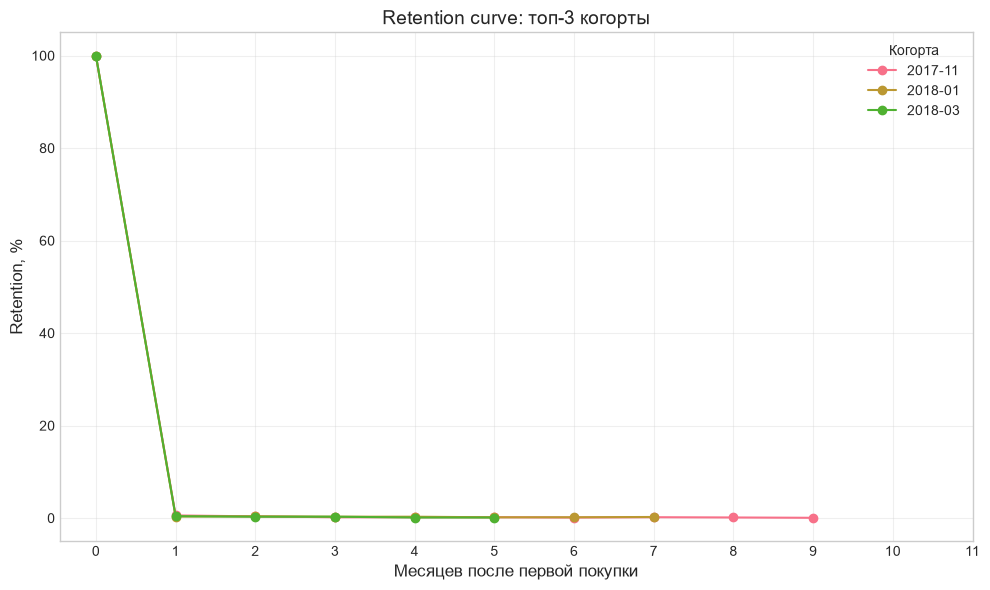

In [8]:
# Берём 3 крупные когорты
top_cohorts = cohort_sizes.sort_values(ascending=False).head(3).index

plt.figure(figsize=(10, 6))

for cohort in top_cohorts:
    if cohort in retention_matrix_clean.index:
        data = retention_matrix_clean.loc[cohort] * 100
        plt.plot(data.index, data.values, marker='o', label=str(cohort))

plt.title('Retention curve: топ-3 когорты', fontsize=14)
plt.xlabel('Месяцев после первой покупки', fontsize=12)
plt.ylabel('Retention, %', fontsize=12)
plt.xticks(range(0, 12))
plt.legend(title='Когорта')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed_data/retention_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# ключевые метрики retention

In [9]:
print("=== КЛЮЧЕВЫЕ МЕТРИКИ RETENTION ===\n")

# Retention на 1-й, 3-й, 6-й месяц (в среднем по когортам)
for month in [1, 3, 6]:
    if month in retention_matrix_clean.columns:
        avg = retention_matrix_clean[month].mean() * 100
        print(f"Средний retention через {month} мес.: {avg:.2f}%")

print()

# Общая возвращаемость (клиенты с 2+ заказами)
customer_orders = master.groupby('customer_unique_id').size()
returned = customer_orders >= 2

print(f"Клиентов всего: {len(customer_orders):,}")
print(f"Вернулись (2+ заказа): {returned.sum():,}")
print(f"Общая возвращаемость: {returned.mean():.2%}")
print()

# Распределение по числу заказов
print("Распределение клиентов по числу заказов:")
print(customer_orders.value_counts().sort_index().head(10))

=== КЛЮЧЕВЫЕ МЕТРИКИ RETENTION ===

Средний retention через 1 мес.: 0.48%
Средний retention через 3 мес.: 0.25%
Средний retention через 6 мес.: 0.26%

Клиентов всего: 93,350
Вернулись (2+ заказа): 2,801
Общая возвращаемость: 3.00%

Распределение клиентов по числу заказов:
1     90549
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


In [12]:
# Все месяцы для дашборда
print("Retention по месяцам (средний по когортам):")
print()

retention_for_bi = []

# Месяц 0 — всегда 100% (по определению)
retention_for_bi.append({'Месяц': 0, 'Retention': 1.0})

for month in range(1, 13):
    if month in retention_matrix_clean.columns:
        avg = retention_matrix_clean[month].mean()
        retention_for_bi.append({'Месяц': month, 'Retention': round(avg, 4)})

# Превращаем в DataFrame
retention_df = pd.DataFrame(retention_for_bi)

print(retention_df)
print()

for _, row in retention_df.iterrows():
    print(f"  {row['Retention']:.4f}")

Retention по месяцам (средний по когортам):

    Месяц  Retention
0       0     1.0000
1       1     0.0048
2       2     0.0034
3       3     0.0025
4       4     0.0029
5       5     0.0023
6       6     0.0026
7       7     0.0021
8       8     0.0021
9       9     0.0017
10     10     0.0026
11     11     0.0021

  1.0000
  0.0048
  0.0034
  0.0025
  0.0029
  0.0023
  0.0026
  0.0021
  0.0021
  0.0017
  0.0026
  0.0021
